# ROUND 1 ASSESSMENT Q2 


**IMPORTING OF ALL LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
plt.style.use("ggplot")


## Importing Data File


In [2]:
df = pd.read_csv("fred_gva.csv")

## Data Understanding


In [3]:
df.shape
df.columns

df['observation_date'] = pd.to_datetime(df['observation_date'])
df.dtypes

observation_date    datetime64[ns]
A193RC1Q027SBEA            float64
A195RC1Q027SBEA            float64
A2009C1Q027SBEA            float64
A358RC1Q027SBEA            float64
A765RC1Q027SBEA            float64
A766RC1Q027SBEA            float64
A767RC1Q027SBEA            float64
B359RC1Q027SBEA            float64
B701RC1Q027SBEA            float64
B702RC1Q027SBEA            float64
GDP                        float64
dtype: object

## Data Preparation


In [4]:
dfcopy = df[['observation_date', 'A193RC1Q027SBEA', 'A195RC1Q027SBEA',
       'A2009C1Q027SBEA', 'A358RC1Q027SBEA', 'A765RC1Q027SBEA',
       'A766RC1Q027SBEA', 'A767RC1Q027SBEA', 'B359RC1Q027SBEA',
       'B701RC1Q027SBEA', 'B702RC1Q027SBEA', 'GDP']].copy()

#Renaming of columns
dfnew = dfcopy.rename(columns = {'observation_date': 'Time', 
                     'A193RC1Q027SBEA': 'Households and Institutions', 
                     'A195RC1Q027SBEA': 'Business', 
                     'A2009C1Q027SBEA': 'Gross Housing Value Added', 
                     'A358RC1Q027SBEA': 'Nonfarm', 
                     'A765RC1Q027SBEA': 'General Government', 
                     'A766RC1Q027SBEA': 'Federal', 
                     'A767RC1Q027SBEA': 'State and local', 
                     'B359RC1Q027SBEA': 'Farm', 
                     'B701RC1Q027SBEA': 'Households', 
                     'B702RC1Q027SBEA': 'Nonprofit institutions serving households', 
                     'GDP': 'Gross domestic product'})


In [5]:
dfnew.loc[dfnew.duplicated(subset = ['Time'])] #No duplicates



,Time,Households and Institutions,Business,Gross Housing Value Added,Nonfarm,General Government,Federal,State and local,Farm,Households,Nonprofit institutions serving households,Gross domestic product


## Part a: Clean & filter to the requested quarters

In [6]:
dfnew['year'] = dfnew['Time'].dt.year
dfnew["quarter"] = dfnew['Time'].dt.quarter

targets = [(2024, 1), (2023, 4), (2023, 1)]


filtered = dfnew[dfnew[["year", "quarter"]].apply(tuple, axis=1).isin(targets)]

filtered = filtered.drop(columns = ["year", "quarter"])


time_map = {
    "2023-01-01": "Q1 2023",
    "2023-10-01": "Q4 2023",
    "2024-01-01": "Q1 2024"
}

# Replace values in Time column
filtered["Time"] = filtered["Time"].astype(str).map(time_map)
filtered = filtered.reset_index(drop = True)
filtered

,Time,Households and Institutions,Business,Gross Housing Value Added,Nonfarm,General Government,Federal,State and local,Farm,Households,Nonprofit institutions serving households,Gross domestic product
0,Q1 2023,3362.675,20988.525,2481.683,20740.762,2813.160,907.667,1905.493,247.763,1947.762,1414.912,27164.359
1,Q4 2023,3537.483,21819.837,2613.752,21623.441,2939.647,950.873,1988.773,196.396,2050.274,1487.209,28296.967
2,Q1 2024,3615.476,22016.021,2666.894,21831.386,2992.572,967.049,2025.523,184.636,2094.827,1520.648,28624.069


## Part b: Gather data starting from ‘1950-01-01’ to ‘2024-01–01’


In [7]:
filtered_range = (dfnew["Time"] >= "1950-01-01") & (dfnew["Time"] <= "2024-01-01")
range_date = dfnew.loc[filtered_range]
range_date = range_date.drop(columns = ["year", "quarter"])
range_date = range_date.reset_index(drop = True)
range_date



,Time,Households and Institutions,Business,Gross Housing Value Added,Nonfarm,General Government,Federal,State and local,Farm,Households,Nonprofit institutions serving households,Gross domestic product
0,1950-01-01,17.258,232.582,15.993,214.879,30.988,19.098,11.890,17.703,12.575,4.684,280.828
1,1950-04-01,17.585,241.558,16.419,223.656,31.241,19.173,12.068,17.902,12.815,4.770,290.383
2,1950-07-01,18.096,257.435,16.878,238.324,32.622,20.237,12.385,19.111,13.247,4.849,308.153
3,1950-10-01,18.764,266.085,17.372,245.899,35.096,22.405,12.691,20.186,13.555,5.209,319.945
4,1951-01-01,19.431,278.530,17.903,257.330,38.039,24.947,13.092,21.200,14.162,5.269,336.000
...,...,...,...,...,...,...,...,...,...,...,...,...
292,2023-01-01,3362.675,20988.525,2481.683,20740.762,2813.160,907.667,1905.493,247.763,1947.762,1414.912,27164.359
293,2023-04-01,3415.084,21190.822,2523.881,20963.120,2847.909,921.747,1926.162,227.702,1979.276,1435.809,27453.815
294,2023-07-01,3473.788,21594.734,2567.747,21377.379,2899.174,938.461,1960.713,217.355,2013.602,1460.187,27967.697
295,2023-10-01,3537.483,21819.837,2613.752,21623.441,2939.647,950.873,1988.773,196.396,2050.274,1487.209,28296.967


## CSV File

In [8]:
range_date.to_csv("gva_1950_2024.csv", index=False)

## Part C: Data Visualisation

<function matplotlib.pyplot.show(close=None, block=None)>

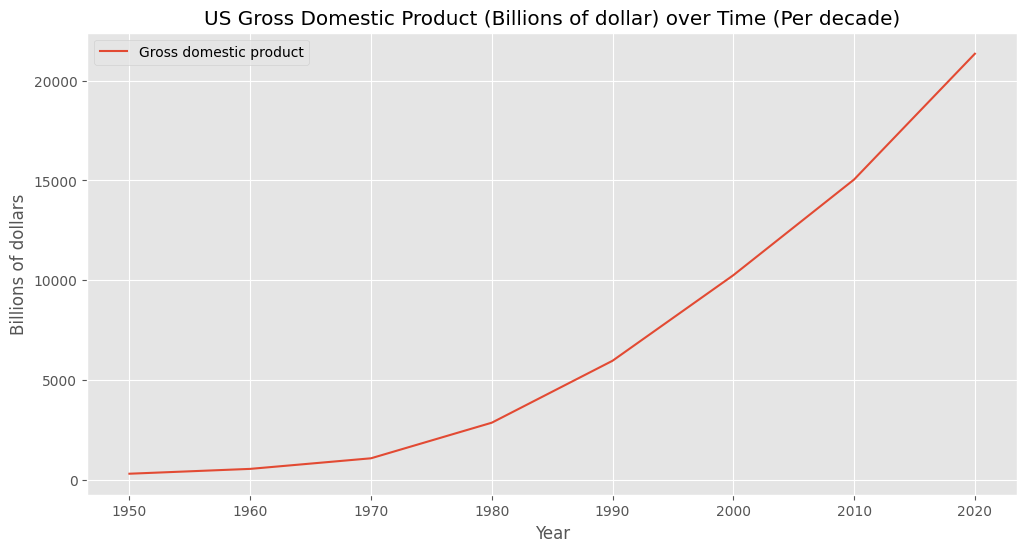

In [9]:
dfnew['Year'] = dfnew['Time'].dt.year
annual_means = (dfnew.groupby("Year", as_index=False).mean(numeric_only=True))
decades = list(range(1950,2030,10))
annual_decades = (annual_means[annual_means["Year"].isin(decades)].sort_values("Year").reset_index(drop=True))
annual_decades = annual_decades.drop(columns=["year", "quarter"]) 


results = annual_decades.plot(x = 'Year', y = 'Gross domestic product', kind = 'line', title = 'US Gross Domestic Product (Billions of dollar) over Time (Per decade)', figsize=(12,6), legend = True)
plt.ylabel("Billions of dollars")
plt.show

In [10]:
annual_decades


,Year,Households and Institutions,Business,Gross Housing Value Added,Nonfarm,General Government,Federal,State and local,Farm,Households,Nonprofit institutions serving households,Gross domestic product
0,1950,17.92575,249.41500,16.66550,230.68950,32.48675,20.22825,12.25850,18.72550,13.04800,4.87800,299.82725
1,1960,45.03075,426.20450,40.40875,408.03350,71.14750,41.66125,29.48625,18.17075,32.84650,12.18450,542.38225
2,1970,94.59425,815.94450,78.78375,792.25975,162.77125,82.45500,80.31650,23.68450,61.15400,33.44100,1073.31050
3,1980,258.14975,2225.79975,203.97875,2174.43150,373.35875,159.82850,213.53025,51.36825,158.80625,99.34375,2857.30850
4,1990,636.33400,4541.95125,486.98225,4464.16975,784.85900,306.69950,478.15950,77.78175,367.56475,268.76900,5963.14450
5,2000,1190.73475,7875.91925,880.61650,7799.26300,1184.29750,360.31550,823.98225,76.65625,692.32675,498.40775,10250.95200
6,2010,1965.03775,11137.84575,1443.86900,11020.80250,1946.08775,639.99350,1306.09400,117.04300,1150.69650,814.34125,15048.97100
7,2020,2779.75375,16075.73500,1990.23400,15956.69325,2498.61575,787.36600,1711.25025,119.04175,1562.16675,1217.58750,21354.10475


1. Overall GDP growth (1950 → 2020)
	* US GDP rose from ~300 billion in 1950 to ~21 trillion in 2020 (in nominal terms).
	* The growth is not linear - it’s exponential, with acceleration especially after 1980.
	* This reflects long-run economic expansion, population growth, productivity, globalization, and technology.

⸻

2. Sector dominance
	*	Business sector is the largest contributor throughout - from ~250 in 1950 to ~16,000 in 2020. This shows that private enterprise is the main driver of US GDP.
	* Nonfarm sector closely follows business, showing the centrality of non-agricultural industries.

⸻

3. Decline of agriculture (Farm sector)
	*	In 1950, farm output was ~18.7 → by 2020 it’s ~119.
	*	While it increased in absolute terms, its share of GDP shrank drastically (from ~6% in 1950 to <1% by 2020).
	*	Classic economic development pattern: as countries industrialize, agriculture’s share falls.

⸻

4. Government contributions
	*	General Government grows from ~32 (1950) → ~2,500 (2020).
	*	Federal vs. State & Local:
	*	Federal remains smaller (~20 → ~787).
	*	State & Local expand steadily (~12 → ~1,711).
	*	Insight: State & Local governments play a larger role in economic activity than the federal government.

⸻

5. Households & Nonprofits
	*	Households rise strongly (from ~13 in 1950 to ~1,562 in 2020).
	*	Nonprofit Institutions Serving Households (NPISH) show massive growth — from ~5 in 1950 to ~1,218 in 2020. This reflects the increasing importance of NGOs, charities, and non-market social services in the US economy.

⸻

6. Structural transformation (relative shares)
	*	1950s economy: More balanced — farm, government, and households had noticeable shares.
	*	2020 economy: Dominated by business and nonfarm industries, with government and nonprofits growing but still much smaller in comparison.

⸻

7. Key patterns for reporting
	*	Exponential GDP growth → US economy expanded ~70× in nominal terms since 1950.
	*	Shift from agriculture → industry/services → Farm’s relative role collapsed.
	*	Rising government and nonprofit contributions → especially in later decades.
	*	Business remains the central engine of GDP.